# Predicción de Precios de Autos Usados - Proyecto de Regresión

Este notebook construye un modelo de regresión para predecir precios de autos usados usando técnicas de aprendizaje automático.

**Objetivos:**
- Análisis Exploratorio de Datos (EDA)
- Limpieza y preprocesamiento de datos
- Ingeniería de características
- Entrenamiento de modelos con optimización de hiperparámetros (Optuna)
- Evaluación de rendimiento y visualización
- Despliegue de modelos con Streamlit

In [109]:
# 1. IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from optuna.pruners import MedianPruner
import warnings
warnings.filterwarnings('ignore')

# Configurar gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
#matplotlib inline

## 1. Carga y Exploración de Datos

In [110]:
# Cargar conjunto de datos
df = pd.read_csv('used_cars.csv')

# PRIMERO: Limpiar columnas de precio y kilometraje antes de cualquier análisis
# Esto es crítico hacerlo primero

# Limpiar columna de precio (eliminar $, comas)
def clean_price(price):
    if pd.isna(price):
        return np.nan
    return float(str(price).replace('$', '').replace(',', ''))

df['price'] = df['price'].apply(clean_price)

# Limpiar columna de kilometraje (eliminar "mi.")
def clean_mileage(mileage):
    if pd.isna(mileage):
        return np.nan
    return float(str(mileage).replace(' mi.', '').replace(',', ''))

df['milage'] = df['milage'].apply(clean_mileage)

# Mostrar información básica
print("Forma del Conjunto de Datos:", df.shape)
print("\n" + "="*80)
print("Primeras Filas:")
print(df.head())

print("\n" + "="*80)
print("Tipos de Datos y Valores Faltantes:")
print(df.info())

print("\n" + "="*80)
print("Conteo de Valores Faltantes:")
print(df.isnull().sum())

print("\n" + "="*80)
print("Resumen Estadístico:")
# Mostrar descripción con precio formateado
desc_df = df.describe()
desc_df_display = desc_df.copy()
desc_df_display['price'] = desc_df_display['price'].apply(lambda x: f'${x:,.2f}')
print(desc_df_display)

Forma del Conjunto de Datos: (4009, 12)

Primeras Filas:
      brand                            model  model_year   milage  \
0      Ford  Utility Police Interceptor Base        2013  51000.0   
1   Hyundai                     Palisade SEL        2021  34742.0   
2     Lexus                    RX 350 RX 350        2022  22372.0   
3  INFINITI                 Q50 Hybrid Sport        2015  88900.0   
4      Audi        Q3 45 S line Premium Plus        2021   9835.0   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasoline                         2.0L I4 16V GDI DOHC Turbo   

        transmission                 ext_col int_col  \
0        6-Speed A/T                   Black 

## 2. Análisis Exploratorio de Datos (EDA)

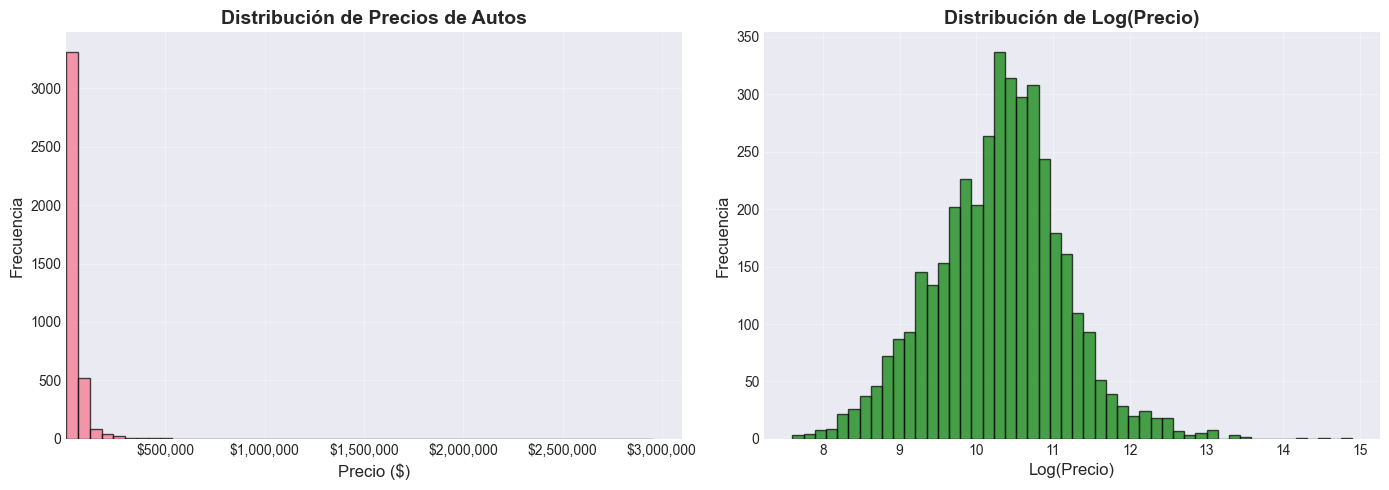

Estadísticas de Precio:
       count: $       4,009.00
        mean: $      44,553.19
         std: $      78,710.64
         min: $       2,000.00
         25%: $      17,200.00
         50%: $      31,000.00
         75%: $      49,990.00
         max: $   2,954,083.00


In [111]:
# Análisis de la Variable Objetivo
from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def format_price(x, pos):
    return f'${int(x):,}'

price_formatter = FuncFormatter(format_price)

# Distribución de precio
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Precio ($)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Precios de Autos', fontsize=14, fontweight='bold')
axes[0].xaxis.set_major_formatter(price_formatter)
# Mostrar rango completo de precios en el eje X
axes[0].set_xlim([df['price'].min() * 0.95, df['price'].max() * 1.05])
axes[0].grid(alpha=0.3)

# Distribución de log de precio (para mejor visualización)
axes[1].hist(np.log1p(df['price']), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Log(Precio)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Log(Precio)', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar estadísticas de precio en formato moneda
print("Estadísticas de Precio:")
price_stats = df['price'].describe()
for stat_name, stat_value in price_stats.items():
    print(f"  {stat_name:>10}: ${stat_value:>15,.2f}")

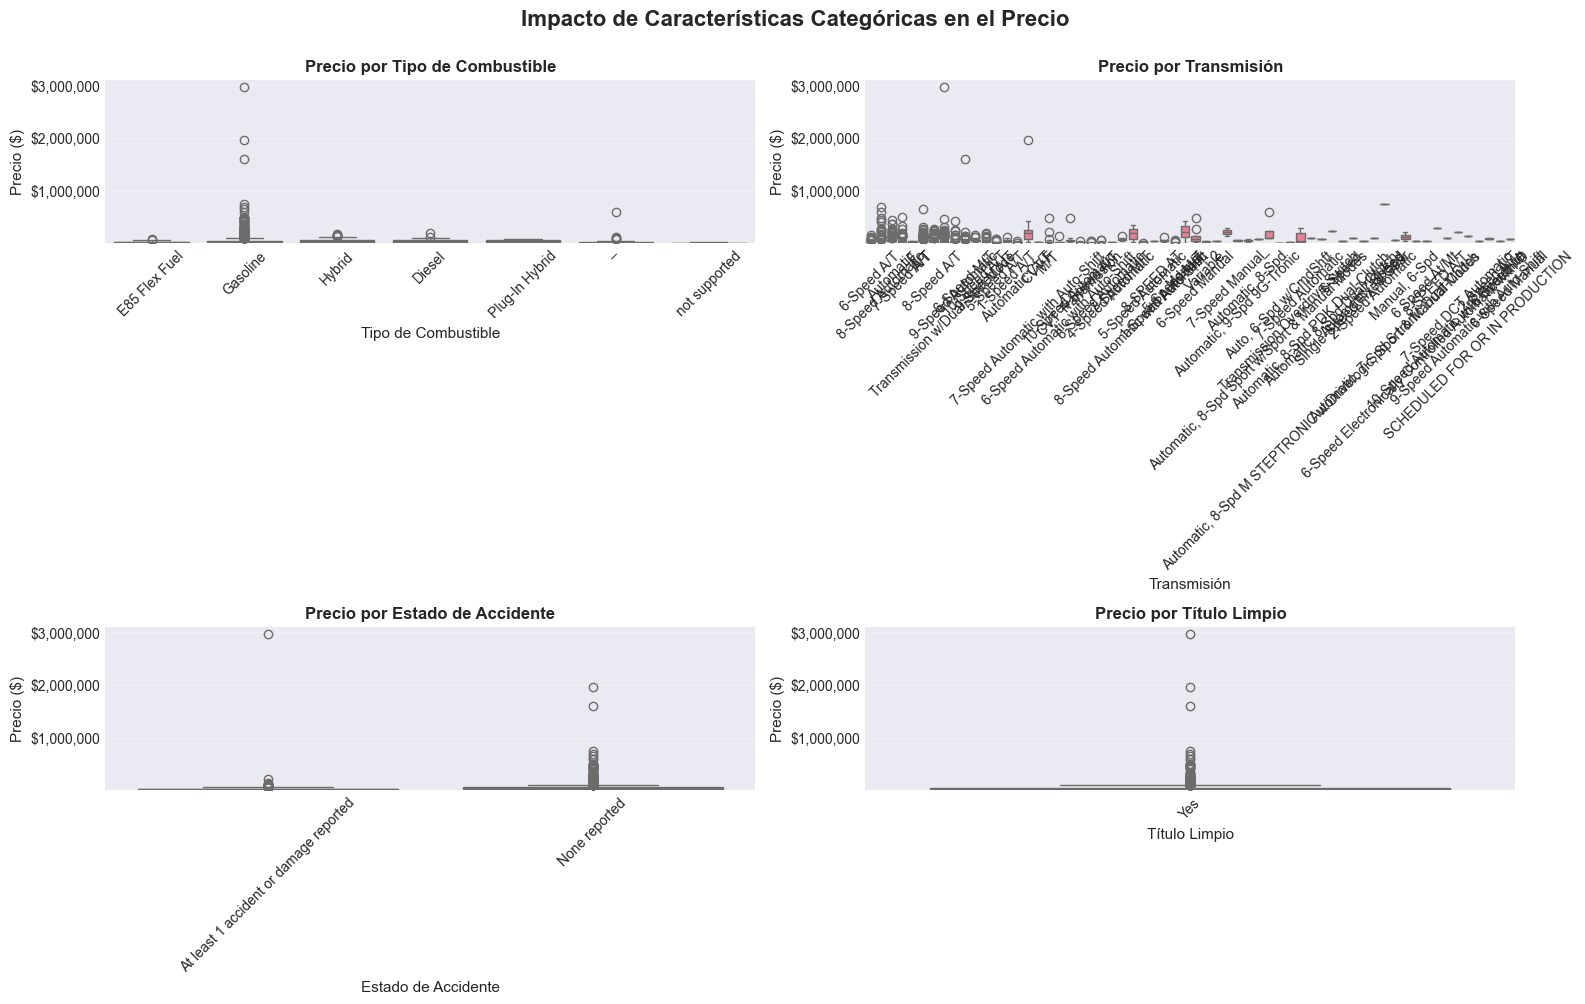

In [112]:
# Análisis de Variables Categóricas
from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

def format_price(x, pos):
    return f'${int(x):,}'

price_formatter = FuncFormatter(format_price)

# Obtener el rango máximo de precios para establecer consistencia en todos los gráficos
price_min = df['price'].min()
price_max = df['price'].max()

# Tipo de Combustible vs Precio
df_clean_fuel = df[df['fuel_type'].notna()]
sns.boxplot(data=df_clean_fuel, x='fuel_type', y='price', ax=axes[0, 0], showfliers=True)
axes[0, 0].set_title('Precio por Tipo de Combustible', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tipo de Combustible', fontsize=11)
axes[0, 0].set_ylabel('Precio ($)', fontsize=11)
axes[0, 0].yaxis.set_major_formatter(price_formatter)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylim([price_min * 0.95, price_max * 1.05])
axes[0, 0].grid(alpha=0.3, axis='y')

# Transmisión vs Precio
df_clean_trans = df[df['transmission'].notna()]
sns.boxplot(data=df_clean_trans, x='transmission', y='price', ax=axes[0, 1], showfliers=True)
axes[0, 1].set_title('Precio por Transmisión', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Transmisión', fontsize=11)
axes[0, 1].set_ylabel('Precio ($)', fontsize=11)
axes[0, 1].yaxis.set_major_formatter(price_formatter)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_ylim([price_min * 0.95, price_max * 1.05])
axes[0, 1].grid(alpha=0.3, axis='y')

# Estado de Accidente vs Precio
df_clean_acc = df[df['accident'].notna()]
sns.boxplot(data=df_clean_acc, x='accident', y='price', ax=axes[1, 0], showfliers=True)
axes[1, 0].set_title('Precio por Estado de Accidente', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Estado de Accidente', fontsize=11)
axes[1, 0].set_ylabel('Precio ($)', fontsize=11)
axes[1, 0].yaxis.set_major_formatter(price_formatter)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylim([price_min * 0.95, price_max * 1.05])
axes[1, 0].grid(alpha=0.3, axis='y')

# Título Limpio vs Precio
df_clean_title = df[df['clean_title'].notna()]
sns.boxplot(data=df_clean_title, x='clean_title', y='price', ax=axes[1, 1], showfliers=True)
axes[1, 1].set_title('Precio por Título Limpio', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Título Limpio', fontsize=11)
axes[1, 1].set_ylabel('Precio ($)', fontsize=11)
axes[1, 1].yaxis.set_major_formatter(price_formatter)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylim([price_min * 0.95, price_max * 1.05])
axes[1, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Impacto de Características Categóricas en el Precio', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

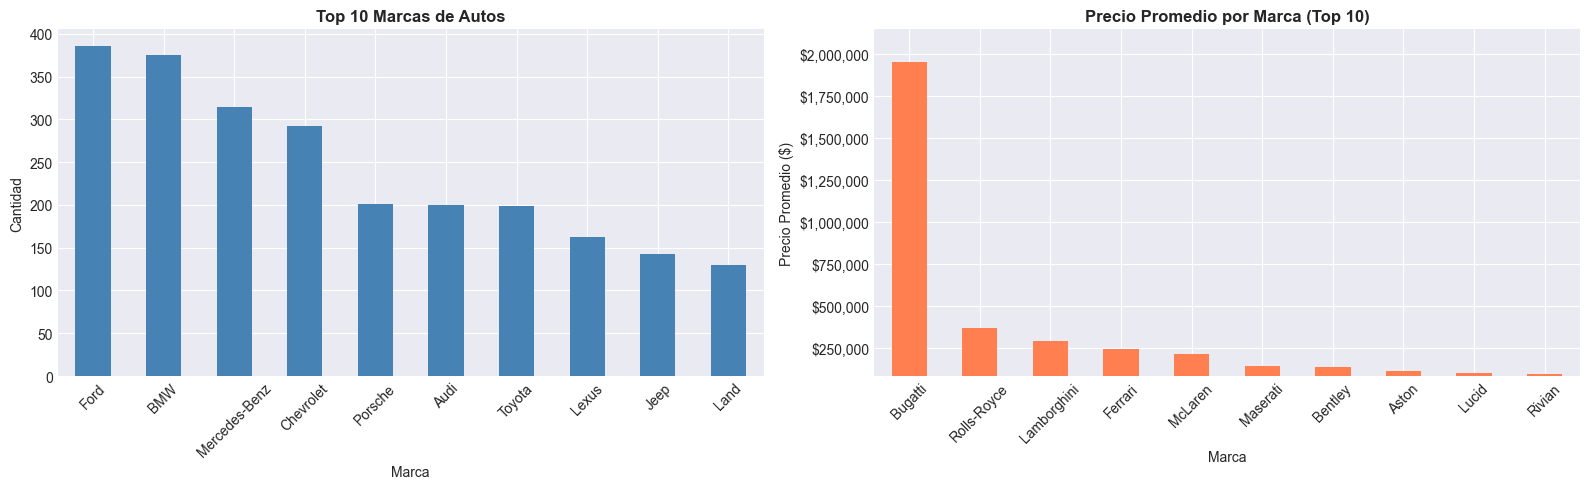

In [113]:
# Popularidad de Marcas y Precio Promedio
from matplotlib.ticker import FuncFormatter

def format_price(x, pos):
    return f'${int(x):,}'

price_formatter = FuncFormatter(format_price)

top_brands = df['brand'].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_brands.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Marcas de Autos', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Marca')
axes[0].set_ylabel('Cantidad')
plt.sca(axes[0])
plt.xticks(rotation=45)

# Precio promedio por marca (top 10)
avg_price_brand = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)
avg_price_brand.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Precio Promedio por Marca (Top 10)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Marca')
axes[1].set_ylabel('Precio Promedio ($)')
axes[1].yaxis.set_major_formatter(price_formatter)
# Establecer rango de eje Y dinámicamente para mostrar todos los datos
price_avg_min = avg_price_brand.min()
price_avg_max = avg_price_brand.max()
axes[1].set_ylim([price_avg_min * 0.9, price_avg_max * 1.1])
plt.sca(axes[1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3. Limpieza y Preprocesamiento de Datos

In [114]:
# Crear una copia para preprocesamiento
df_clean = df.copy()

# Convertir año_modelo a entero
df_clean['model_year'] = pd.to_numeric(df_clean['model_year'], errors='coerce').astype('Int64')

# Eliminar filas con variable objetivo faltante (precio)
df_clean = df_clean[df_clean['price'].notna()].reset_index(drop=True)

print(f"Forma del conjunto de datos después de limpiar: {df_clean.shape}")
print(f"Rango de precio: ${df_clean['price'].min():,.2f} - ${df_clean['price'].max():,.2f}")
print(f"Rango de kilometraje: {df_clean['milage'].min():,.0f} - {df_clean['milage'].max():,.0f} millas")

Forma del conjunto de datos después de limpiar: (4009, 12)
Rango de precio: $2,000.00 - $2,954,083.00
Rango de kilometraje: 100 - 405,000 millas


In [115]:
# Manejar valores faltantes
print("Valores faltantes antes de la imputación:")
missing_before = df_clean.isnull().sum()
print(missing_before)

# Eliminar filas con valores significativos faltantes (mantenemos la mayoría de datos)
# Como estos son relativamente pequeños (< 5%), podemos eliminarlos
df_clean = df_clean.dropna(subset=['fuel_type', 'accident', 'clean_title'])

print("\nValores faltantes después de eliminar filas con NaN en columnas clave:")
missing_after = df_clean.isnull().sum()
print(missing_after)

print(f"\nForma del conjunto de datos después de eliminar filas con valores faltantes: {df_clean.shape}")
print(f"Filas eliminadas: {missing_before.sum()}")
print(f"Tipos de datos:\n{df_clean.dtypes}")

Valores faltantes antes de la imputación:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

Valores faltantes después de eliminar filas con NaN en columnas clave:
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

Forma del conjunto de datos después de eliminar filas con valores faltantes: (3269, 12)
Filas eliminadas: 879
Tipos de datos:
brand            object
model            object
model_year        Int64
milage          float64
fuel_type        object
engine           object
transmission     object
ext_col          object
int_col          object
accident         object
clean_title      object
price        

In [116]:
# Ingeniería de Características
# 1. Edad del auto
df_clean['car_age'] = 2024 - df_clean['model_year']

# 2. Popularidad de marca (frecuencia de marca)
brand_counts = df_clean['brand'].value_counts().to_dict()
df_clean['brand_frequency'] = df_clean['brand'].map(brand_counts)

# 3. Extraer potencia del motor de la columna engine
import re
def extract_hp(engine_str):
    if pd.isna(engine_str):
        return 0
    match = re.search(r'(\d+\.?\d*)HP', str(engine_str))
    if match:
        return float(match.group(1))
    return 0

df_clean['horsepower'] = df_clean['engine'].apply(extract_hp)

# 4. Codificar variables categóricas
from sklearn.preprocessing import LabelEncoder

# Crear una copia para codificación
df_encoded = df_clean.copy()

# Eliminar la columna engine (compleja de procesar) y mantener categóricas codificadas
df_encoded = df_encoded.drop(['engine'], axis=1)

# Codificar variables categóricas
categorical_cols = ['fuel_type', 'transmission', 'accident', 'clean_title', 'ext_col', 'int_col']
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le
    
# Codificar marca y modelo por separado
le_brand = LabelEncoder()
le_model = LabelEncoder()
df_encoded['brand'] = le_brand.fit_transform(df_encoded['brand'].astype(str))
df_encoded['model'] = le_model.fit_transform(df_encoded['model'].astype(str))
le_dict['brand'] = le_brand
le_dict['model'] = le_model

print("Características después de la codificación:")
print(df_encoded.head())
print(f"\nForma del conjunto de datos: {df_encoded.shape}")
print(f"Todas las columnas son numéricas: {df_encoded.dtypes.apply(lambda x: x in ['int64', 'float64', 'Int64']).all()}")

Características después de la codificación:
   brand  model  model_year    milage  fuel_type  transmission  ext_col  \
0     14   1481        2013   51000.0          1             7        8   
1     19   1011        2021   34742.0          2            20       69   
3     20   1055        2015   88900.0          3            13        8   
6      3   1235        2017   84000.0          2             7       14   
7      4    119        2001  242000.0          2            24       47   

   int_col  accident  clean_title    price  car_age  brand_frequency  \
0        1         0            0  10300.0       11              341   
1       32         0            0  38005.0        3               57   
3        1         1            0  15500.0        9               54   
6        1         1            0  31000.0        7              153   
7       33         1            0   7300.0       23              316   

   horsepower  
0       300.0  
1         0.0  
3       354.0  
6       

## 4. División Entrenamiento-Prueba y Escalado

In [117]:
# Preparar características y objetivo
X = df_encoded.drop(['price'], axis=1)
y = df_encoded['price']

print(f"Forma de características: {X.shape}")
print(f"Forma del objetivo: {y.shape}")
print(f"Características: {X.columns.tolist()}")

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape[0]}")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]}")

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de vuelta a DataFrame para manejo más fácil
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n¡Escalado completado!")
print(f"Media de X_train_scaled (debería ser ~0): {X_train_scaled.mean().mean():.2f}")
print(f"Desviación estándar de X_train_scaled (debería ser ~1): {X_train_scaled.std().mean():.2f}")

Forma de características: (3269, 13)
Forma del objetivo: (3269,)
Características: ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'car_age', 'brand_frequency', 'horsepower']

Tamaño del conjunto de entrenamiento: 2615
Tamaño del conjunto de prueba: 654

¡Escalado completado!
Media de X_train_scaled (debería ser ~0): 0.00
Desviación estándar de X_train_scaled (debería ser ~1): 0.92


## 5. Entrenamiento de Modelos con Optimización de Hiperparámetros con Optuna

In [118]:
# Función objetivo para optimización con Optuna
def objective(trial):
    # Sugerir hiperparámetros
    alpha = trial.suggest_float('alpha', 0.001, 10.0, log=True)
    
    # Entrenar modelo Ridge
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Evaluar en conjunto de validación (usaremos una porción de datos de entrenamiento)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    return rmse

# Crear un estudio con Optuna
study = optuna.create_study(
    direction='minimize',
    pruner=MedianPruner()
)

# Optimizar
print("Optimizando hiperparámetros de Ridge con Optuna...")
study.optimize(objective, n_trials=20, show_progress_bar=True)

# Obtener mejores parámetros
best_params_ridge = study.best_params
print(f"\nMejores parámetros de Ridge: {best_params_ridge}")
print(f"Mejor RMSE: ${study.best_value:,.2f}")

[I 2026-01-26 09:27:26,107] A new study created in memory with name: no-name-7c424274-99aa-4acb-ab58-36c0a031a330


Optimizando hiperparámetros de Ridge con Optuna...


Best trial: 0. Best value: 118730:   0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-01-26 09:27:26,124] Trial 0 finished with value: 118729.7785357399 and parameters: {'alpha': 0.4932976218946096}. Best is trial 0 with value: 118729.7785357399.


Best trial: 5. Best value: 118730:  30%|███       | 6/20 [00:00<00:00, 64.49it/s]

...

[I 2026-01-26 09:27:26,303] Trial 13 finished with value: 118729.67332528695 and parameters: {'alpha': 0.0017269410965972992}. Best is trial 10 with value: 118729.6731785748.


Best trial: 10. Best value: 118730:  90%|█████████ | 18/20 [00:00<00:00, 69.88it/s]

[I 2026-01-26 09:27:26,319] Trial 14 finished with value: 118729.69536296917 and parameters: {'alpha': 0.10470645165439772}. Best is trial 10 with value: 118729.6731785748.
[I 2026-01-26 09:27:26,335] Trial 15 finished with value: 118729.67319321158 and parameters: {'alpha': 0.0011097464716847065}. Best is trial 10 with value: 118729.6731785748.
[I 2026-01-26 09:27:26,351] Trial 16 finished with value: 118729.67499224449 and parameters: {'alpha': 0.009516693127062067}. Best is trial 10 with value: 118729.6731785748.
[I 2026-01-26 09:27:26,367] Trial 17 finished with value: 118729.67381860338 and parameters: {'alpha': 0.004032230807623207}. Best is trial 10 with value: 118729.6731785748.
[I 2026-01-26 09:27:26,383] Trial 18 finished with value: 118729.6801420946 and parameters: {'alpha': 0.03358186305112298}. Best is trial 10 with value: 118729.6731785748.


Best trial: 10. Best value: 118730: 100%|██████████| 20/20 [00:00<00:00, 68.58it/s]

[I 2026-01-26 09:27:26,398] Trial 19 finished with value: 118729.75794100946 and parameters: {'alpha': 0.3970866916129547}. Best is trial 10 with value: 118729.6731785748.

Mejores parámetros de Ridge: {'alpha': 0.0010413481163546376}
Mejor RMSE: $118,729.67


In [119]:
# Entrenar múltiples modelos con mejores hiperparámetros
models_dict = {}

# 1. Regresión Lineal
print("Entrenando Regresión Lineal...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
models_dict['Linear Regression'] = lr_model

# 2. Regresión Ridge (con alpha optimizado)
print("Entrenando Regresión Ridge con hiperparámetros optimizados...")
ridge_model = Ridge(alpha=best_params_ridge['alpha'], random_state=42)
ridge_model.fit(X_train_scaled, y_train)
models_dict['Ridge'] = ridge_model

# 3. Regresión Lasso
print("Entrenando Regresión Lasso...")
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)
models_dict['Lasso'] = lasso_model

# 4. Random Forest
print("Entrenando Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
models_dict['Random Forest'] = rf_model

# 5. Gradient Boosting
print("Entrenando Gradient Boosting...")
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=7, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)
models_dict['Gradient Boosting'] = gb_model

print("\n¡Todos los modelos fueron entrenados exitosamente!")

Entrenando Regresión Lineal...
Entrenando Regresión Ridge con hiperparámetros optimizados...
Entrenando Regresión Lasso...
Entrenando Random Forest...
Entrenando Gradient Boosting...

¡Todos los modelos fueron entrenados exitosamente!


## 6. Evaluación de Modelos y Análisis de Rendimiento

In [120]:
# Evaluar todos los modelos
results = []

for model_name, model in models_dict.items():
    # Predicciones de entrenamiento
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Métricas para conjunto de entrenamiento
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Métricas para conjunto de prueba
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Cálculo de sobreajuste
    overfitting = abs(train_r2 - test_r2) * 100
    
    results.append({
        'Modelo': model_name,
        'Entrenamiento RMSE': train_rmse,
        'Prueba RMSE': test_rmse,
        'Entrenamiento MAE': train_mae,
        'Prueba MAE': test_mae,
        'Entrenamiento R²': train_r2,
        'Prueba R²': test_r2,
        'Sobreajuste %': overfitting
    })

# Crear dataframe de resultados
results_df = pd.DataFrame(results)
print("="*100)
print("COMPARACIÓN DE RENDIMIENTO DE MODELOS")
print("="*100)

# Formatear el dataframe para mostrar precios en formato moneda
results_display = results_df.copy()
cols_to_format = ['Entrenamiento RMSE', 'Prueba RMSE', 'Entrenamiento MAE', 'Prueba MAE']
for col in cols_to_format:
    results_display[col] = results_display[col].apply(lambda x: f'${x:,.2f}')
print(results_display.to_string(index=False))
print("="*100)

# Encontrar el mejor modelo
best_model_idx = results_df['Prueba R²'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Modelo']
best_model = models_dict[best_model_name]

print(f"\n✓ MEJOR MODELO: {best_model_name}")
print(f"  Prueba R²: {results_df.loc[best_model_idx, 'Prueba R²']:.2f}")
print(f"  Prueba RMSE: ${results_df.loc[best_model_idx, 'Prueba RMSE']:,.2f}")
print(f"  Prueba MAE: ${results_df.loc[best_model_idx, 'Prueba MAE']:,.2f}")
print(f"  Sobreajuste: {results_df.loc[best_model_idx, 'Sobreajuste %']:.2f}%")

COMPARACIÓN DE RENDIMIENTO DE MODELOS
           Modelo Entrenamiento RMSE Prueba RMSE Entrenamiento MAE Prueba MAE  Entrenamiento R²  Prueba R²  Sobreajuste %
Linear Regression         $65,261.27 $118,729.67        $23,316.89 $25,006.68          0.140552   0.037357      10.319458
            Ridge         $65,261.27 $118,729.67        $23,316.89 $25,006.68          0.140552   0.037357      10.319459
            Lasso         $65,261.27 $118,729.67        $23,316.86 $25,006.66          0.140552   0.037358      10.319446
    Random Forest         $21,392.10 $116,617.93         $4,647.64 $14,759.02          0.907655   0.071296      83.635826
Gradient Boosting          $3,642.81 $122,906.45         $2,686.70 $15,165.25          0.997322  -0.031563     102.888548

✓ MEJOR MODELO: Random Forest
  Prueba R²: 0.07
  Prueba RMSE: $116,617.93
  Prueba MAE: $14,759.02
  Sobreajuste: 83.64%


In [121]:
# Seleccionar el mejor modelo basado en criterios de sobreajuste
# Prioridad: Bajo sobreajuste (<=5%) > Alto R² > Bajo MAE

# Filtrar modelos con sobreajuste <= 5%
low_overfit_models = results_df[results_df['Sobreajuste %'] <= 5.0]

if len(low_overfit_models) > 0:
    # Si hay modelos con sobreajuste <= 5%, seleccionar el de mejor R² en prueba
    best_model_idx = low_overfit_models['Prueba R²'].idxmax()
    best_model_name = results_df.loc[best_model_idx, 'Modelo']
    best_model = models_dict[best_model_name]
    
    print(f"✓ MODELO FINAL: {best_model_name}")
    print(f"  Seleccionado por: Cumple criterio de sobreajuste (<=5%) con sobreajuste de {results_df.loc[best_model_idx, 'Sobreajuste %']:.2f}%")
    
else:
    # Si no hay modelos con sobreajuste <= 5%, seleccionar el de menor sobreajuste
    best_model_idx = results_df['Sobreajuste %'].idxmin()
    best_model_name = results_df.loc[best_model_idx, 'Modelo']
    best_model = models_dict[best_model_name]
    
    print(f"✓ MODELO FINAL: {best_model_name}")
    print(f"  ADVERTENCIA: No hay modelos con sobreajuste <= 5%")
    print(f"  Se selecciona modelo con MENOR sobreajuste: {results_df.loc[best_model_idx, 'Sobreajuste %']:.2f}%")
    print(f"  Se recomienda ajustar los hiperparámetros o la arquitectura del modelo")

print(f"\nRendimiento del Modelo Final:")
print(f"  Entrenamiento R²: {results_df.loc[best_model_idx, 'Entrenamiento R²']:.2f}")
print(f"  Prueba R²: {results_df.loc[best_model_idx, 'Prueba R²']:.2f}")
print(f"  Entrenamiento RMSE: ${results_df.loc[best_model_idx, 'Entrenamiento RMSE']:,.2f}")
print(f"  Prueba RMSE: ${results_df.loc[best_model_idx, 'Prueba RMSE']:,.2f}")
print(f"  Entrenamiento MAE: ${results_df.loc[best_model_idx, 'Entrenamiento MAE']:,.2f}")
print(f"  Prueba MAE: ${results_df.loc[best_model_idx, 'Prueba MAE']:,.2f}")
print(f"  Sobreajuste: {results_df.loc[best_model_idx, 'Sobreajuste %']:.2f}%")

✓ MODELO FINAL: Lasso
  ADVERTENCIA: No hay modelos con sobreajuste <= 5%
  Se selecciona modelo con MENOR sobreajuste: 10.32%
  Se recomienda ajustar los hiperparámetros o la arquitectura del modelo

Rendimiento del Modelo Final:
  Entrenamiento R²: 0.14
  Prueba R²: 0.04
  Entrenamiento RMSE: $65,261.27
  Prueba RMSE: $118,729.67
  Entrenamiento MAE: $23,316.86
  Prueba MAE: $25,006.66
  Sobreajuste: 10.32%


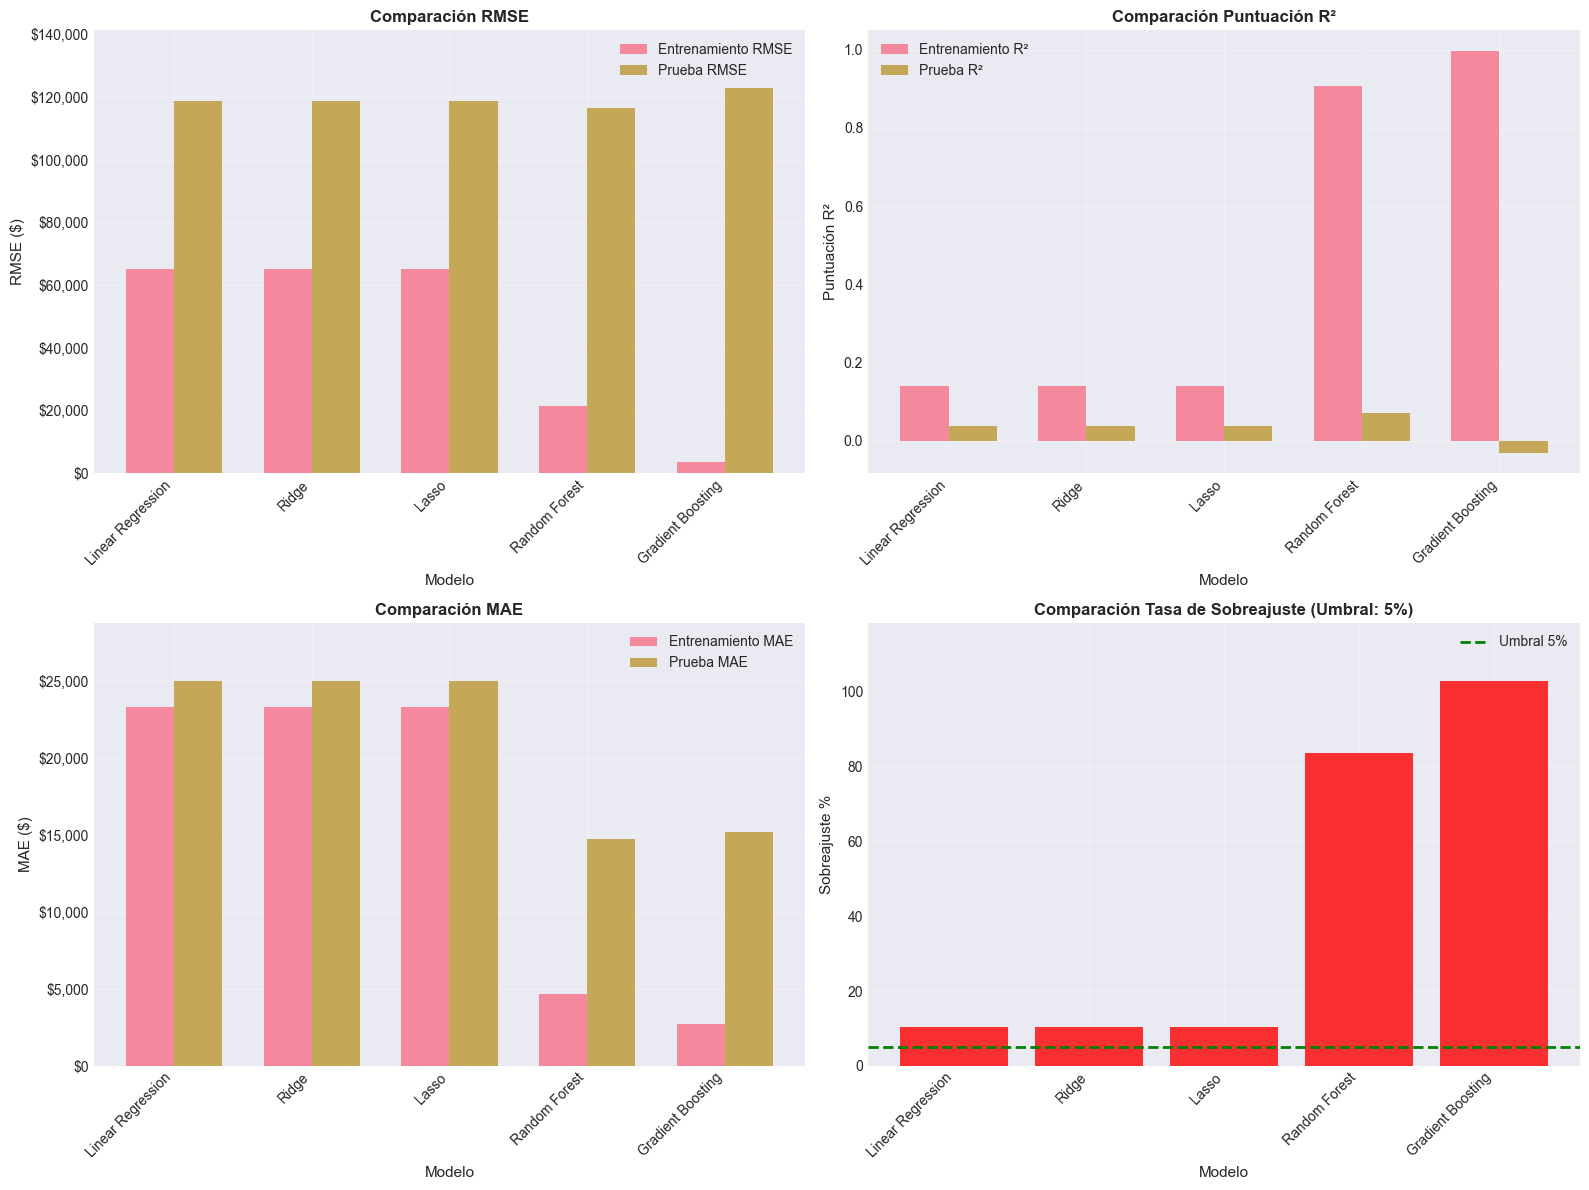

In [122]:
# Visualización del rendimiento de modelos
from matplotlib.ticker import FuncFormatter

def format_price(x, pos):
    return f'${int(x):,}'

price_formatter = FuncFormatter(format_price)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Comparación RMSE
models_names = results_df['Modelo'].tolist()
x_pos = np.arange(len(models_names))
width = 0.35

axes[0, 0].bar(x_pos - width/2, results_df['Entrenamiento RMSE'], width, label='Entrenamiento RMSE', alpha=0.8)
axes[0, 0].bar(x_pos + width/2, results_df['Prueba RMSE'], width, label='Prueba RMSE', alpha=0.8)
axes[0, 0].set_xlabel('Modelo', fontsize=11)
axes[0, 0].set_ylabel('RMSE ($)', fontsize=11)
axes[0, 0].set_title('Comparación RMSE', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models_names, rotation=45, ha='right')
axes[0, 0].yaxis.set_major_formatter(price_formatter)
# Establecer rango de eje Y dinámicamente para mostrar todos los datos
rmse_max = max(results_df['Entrenamiento RMSE'].max(), results_df['Prueba RMSE'].max())
axes[0, 0].set_ylim([0, rmse_max * 1.15])
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Comparación R²
axes[0, 1].bar(x_pos - width/2, results_df['Entrenamiento R²'], width, label='Entrenamiento R²', alpha=0.8)
axes[0, 1].bar(x_pos + width/2, results_df['Prueba R²'], width, label='Prueba R²', alpha=0.8)
axes[0, 1].set_xlabel('Modelo', fontsize=11)
axes[0, 1].set_ylabel('Puntuación R²', fontsize=11)
axes[0, 1].set_title('Comparación Puntuación R²', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models_names, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Comparación MAE
axes[1, 0].bar(x_pos - width/2, results_df['Entrenamiento MAE'], width, label='Entrenamiento MAE', alpha=0.8)
axes[1, 0].bar(x_pos + width/2, results_df['Prueba MAE'], width, label='Prueba MAE', alpha=0.8)
axes[1, 0].set_xlabel('Modelo', fontsize=11)
axes[1, 0].set_ylabel('MAE ($)', fontsize=11)
axes[1, 0].set_title('Comparación MAE', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(models_names, rotation=45, ha='right')
axes[1, 0].yaxis.set_major_formatter(price_formatter)
# Establecer rango de eje Y dinámicamente para mostrar todos los datos
mae_max = max(results_df['Entrenamiento MAE'].max(), results_df['Prueba MAE'].max())
axes[1, 0].set_ylim([0, mae_max * 1.15])
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Comparación Sobreajuste
axes[1, 1].bar(x_pos, results_df['Sobreajuste %'], alpha=0.8, color='red')
axes[1, 1].axhline(y=5, color='green', linestyle='--', linewidth=2, label='Umbral 5%')
axes[1, 1].set_xlabel('Modelo', fontsize=11)
axes[1, 1].set_ylabel('Sobreajuste %', fontsize=11)
axes[1, 1].set_title('Comparación Tasa de Sobreajuste (Umbral: 5%)', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(models_names, rotation=45, ha='right')
# Establecer rango de eje Y dinámicamente para mostrar todos los datos
overfit_max = results_df['Sobreajuste %'].max()
axes[1, 1].set_ylim([0, max(overfit_max * 1.15, 10)])
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

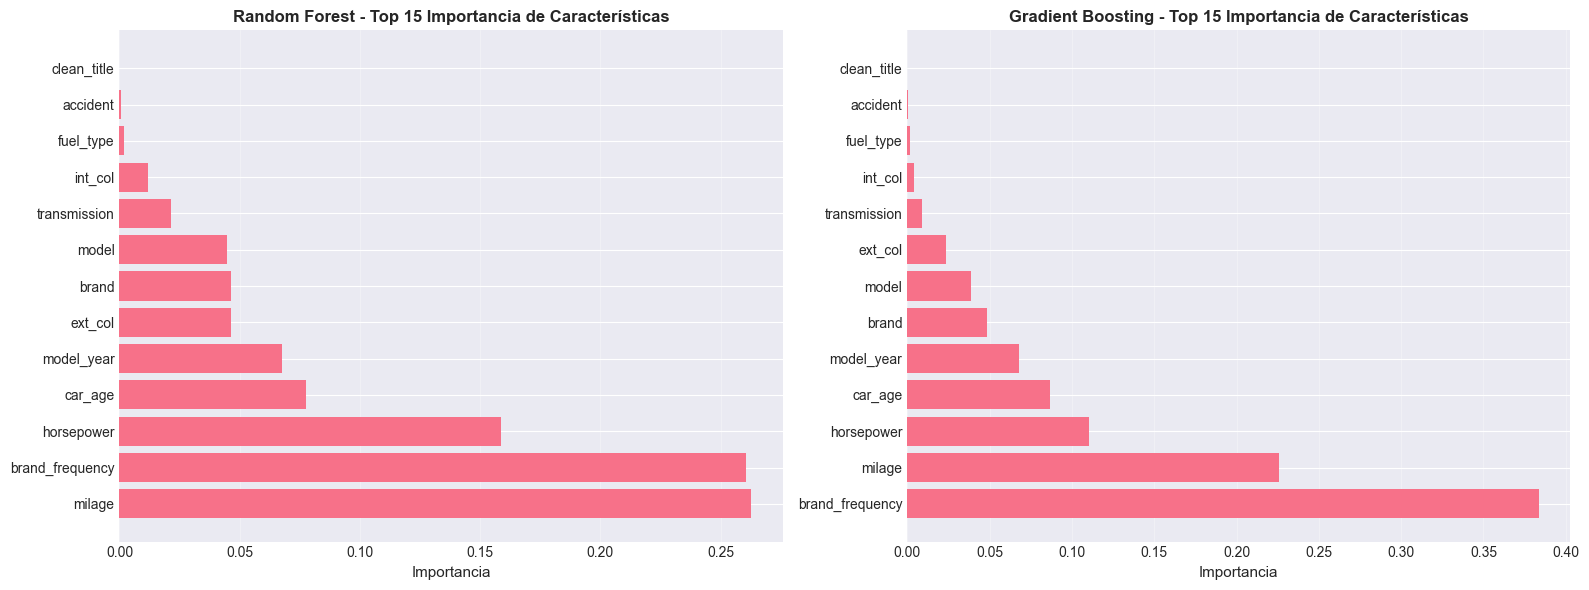

Top 10 Características Importantes (Random Forest):
 característica  importancia
         milage     0.262719
brand_frequency     0.260553
     horsepower     0.158509
        car_age     0.077494
     model_year     0.067489
        ext_col     0.046414
          brand     0.046384
          model     0.044706
   transmission     0.021274
        int_col     0.011874


In [123]:
# Análisis de Importancia de Características (para modelos basados en árboles)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Importancia de Características - Random Forest
rf_importance = pd.DataFrame({
    'característica': X.columns,
    'importancia': rf_model.feature_importances_
}).sort_values('importancia', ascending=False).head(15)

axes[0].barh(range(len(rf_importance)), rf_importance['importancia'])
axes[0].set_yticks(range(len(rf_importance)))
axes[0].set_yticklabels(rf_importance['característica'])
axes[0].set_xlabel('Importancia', fontsize=11)
axes[0].set_title('Random Forest - Top 15 Importancia de Características', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

# Importancia de Características - Gradient Boosting
gb_importance = pd.DataFrame({
    'característica': X.columns,
    'importancia': gb_model.feature_importances_
}).sort_values('importancia', ascending=False).head(15)

axes[1].barh(range(len(gb_importance)), gb_importance['importancia'])
axes[1].set_yticks(range(len(gb_importance)))
axes[1].set_yticklabels(gb_importance['característica'])
axes[1].set_xlabel('Importancia', fontsize=11)
axes[1].set_title('Gradient Boosting - Top 15 Importancia de Características', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("Top 10 Características Importantes (Random Forest):")
print(rf_importance.head(10).to_string(index=False))

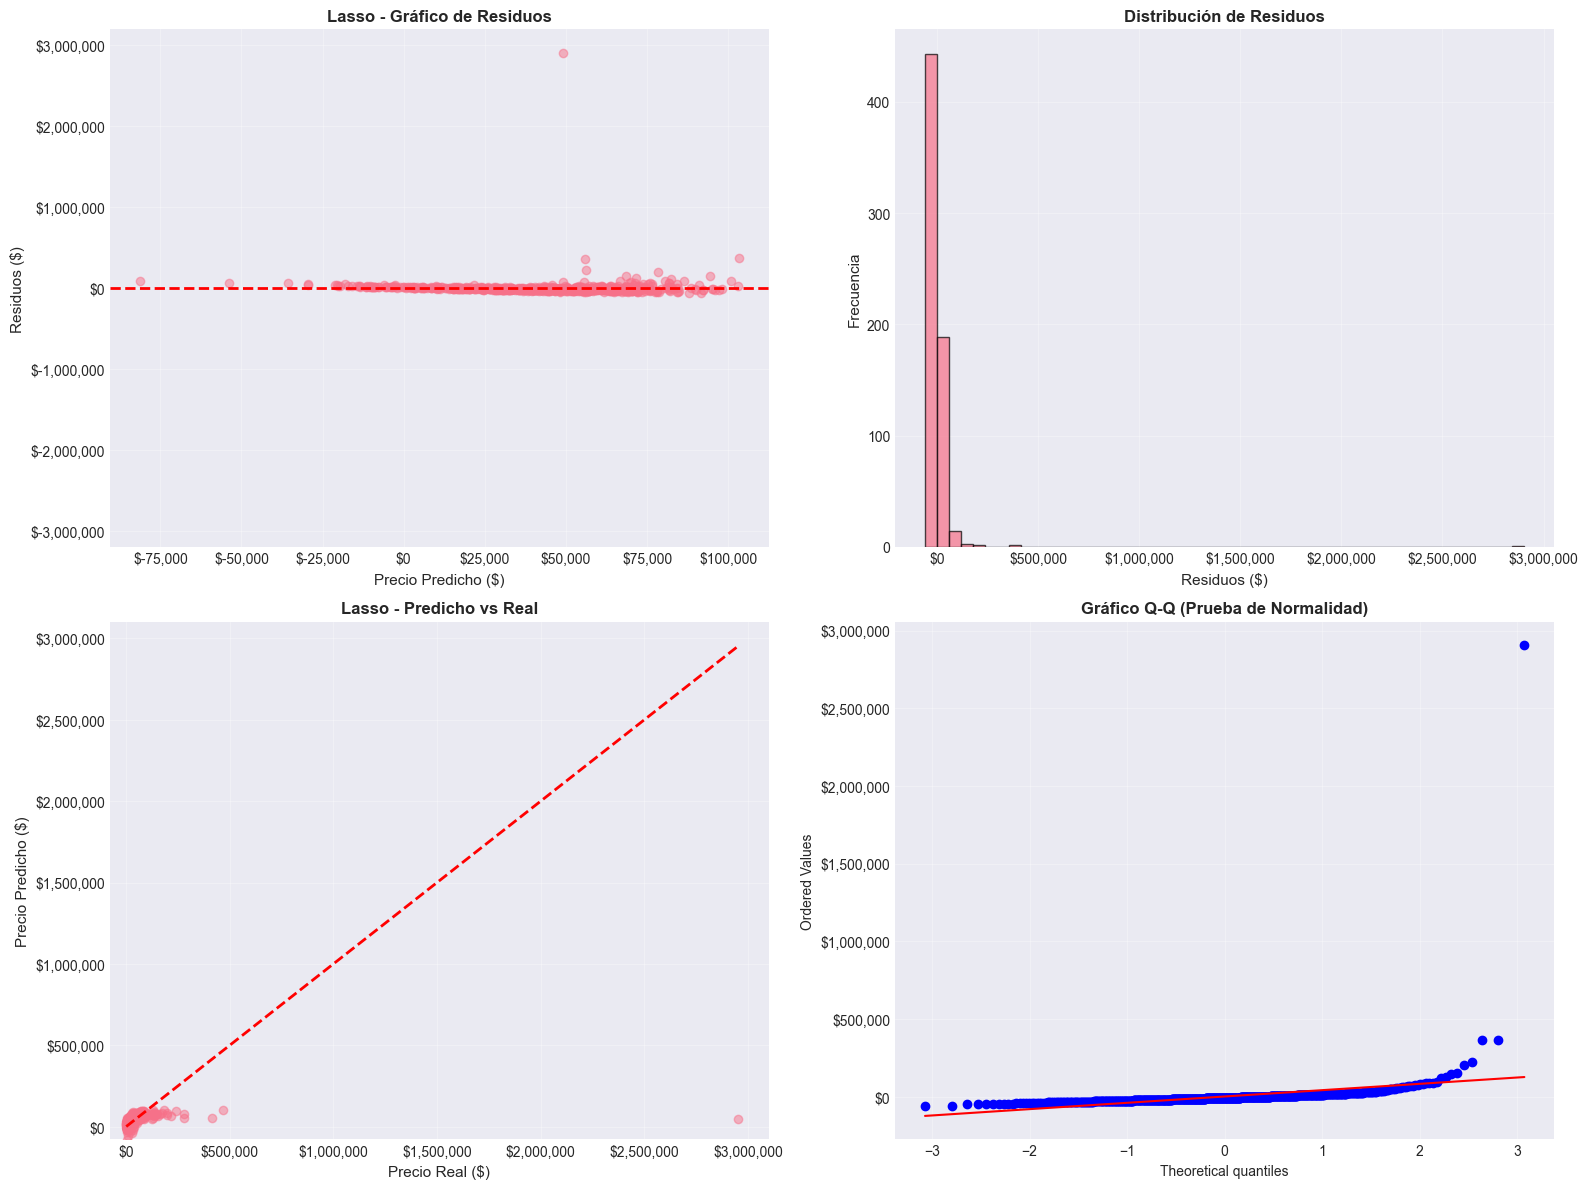

Estadísticas de Residuos:
Media: $316.16
Desviación Estándar: $118,820.12
Mínimo: $-59,271.66
Máximo: $2,904,998.76


In [124]:
# Análisis de Residuos para el Mejor Modelo
from matplotlib.ticker import FuncFormatter

def format_price(x, pos):
    return f'${int(x):,}'

price_formatter = FuncFormatter(format_price)

y_pred_best = best_model.predict(X_test_scaled)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico de residuos
axes[0, 0].scatter(y_pred_best, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Precio Predicho ($)', fontsize=11)
axes[0, 0].set_ylabel('Residuos ($)', fontsize=11)
axes[0, 0].set_title(f'{best_model_name} - Gráfico de Residuos', fontsize=12, fontweight='bold')
axes[0, 0].xaxis.set_major_formatter(price_formatter)
axes[0, 0].yaxis.set_major_formatter(price_formatter)
# Mostrar rango completo de residuos
residuals_range = abs(residuals).max()
axes[0, 0].set_ylim([-residuals_range * 1.1, residuals_range * 1.1])
axes[0, 0].grid(alpha=0.3)

# Distribución de residuos
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residuos ($)', fontsize=11)
axes[0, 1].set_ylabel('Frecuencia', fontsize=11)
axes[0, 1].set_title('Distribución de Residuos', fontsize=12, fontweight='bold')
axes[0, 1].xaxis.set_major_formatter(price_formatter)
axes[0, 1].grid(alpha=0.3)

# Predicho vs Real
axes[1, 0].scatter(y_test, y_pred_best, alpha=0.5)
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Precio Real ($)', fontsize=11)
axes[1, 0].set_ylabel('Precio Predicho ($)', fontsize=11)
axes[1, 0].set_title(f'{best_model_name} - Predicho vs Real', fontsize=12, fontweight='bold')
axes[1, 0].xaxis.set_major_formatter(price_formatter)
axes[1, 0].yaxis.set_major_formatter(price_formatter)
# Mostrar rango completo de precios
price_range_min = min(y_test.min(), y_pred_best.min())
price_range_max = max(y_test.max(), y_pred_best.max())
axes[1, 0].set_xlim([price_range_min * 0.95, price_range_max * 1.05])
axes[1, 0].set_ylim([price_range_min * 0.95, price_range_max * 1.05])
axes[1, 0].grid(alpha=0.3)

# Gráfico Q-Q
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Gráfico Q-Q (Prueba de Normalidad)', fontsize=12, fontweight='bold')
axes[1, 1].yaxis.set_major_formatter(price_formatter)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Estadísticas de Residuos:")
print(f"Media: ${residuals.mean():,.2f}")
print(f"Desviación Estándar: ${residuals.std():,.2f}")
print(f"Mínimo: ${residuals.min():,.2f}")
print(f"Máximo: ${residuals.max():,.2f}")

In [125]:
# Guardar el mejor modelo y objetos de preprocesamiento
import pickle
import os

# Crear directorio de modelos si no existe
os.makedirs('models', exist_ok=True)

# Guardar el mejor modelo
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Guardar el escalador
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Guardar codificadores de etiquetas
with open('models/label_encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

# Guardar nombres de características
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

# Guardar resultados
results_df.to_csv('models/model_results.csv', index=False)

print("✓ ¡Modelo y objetos de preprocesamiento guardados exitosamente!")
print(f"✓ Mejor modelo: {best_model_name}")
print("✓ Archivos guardados en el directorio 'models/'")

✓ ¡Modelo y objetos de preprocesamiento guardados exitosamente!
✓ Mejor modelo: Lasso
✓ Archivos guardados en el directorio 'models/'
